# Analysis of Trips: Bike Sharing in the Bay Area (2014 - 2015)

We end this chapter by applying every method we have learned to a new and large dataset.

- We also introduce [`folium`](https://python-visualization.github.io/folium/latest/), a powerful map-visualization library.
- The [Bay Area Bike Share](http://www.bayareabikeshare.com/) service published a [dataset](http://www.bayareabikeshare.com/open-data) describing every bicycle rental from September 2014 to August 2015 in their system.
- There were $354,152$ rentals in all.
- The columns are:
  - An ID for the rental
  - Duration of the rental, in seconds
  - Start date
  - Name of the Start Station and code for Start Terminal
  - Name of the End Station and code for End Terminal
  - A serial number for the bike
  - Subscriber type and zip code


## Setup

### Imports


In [1]:
# Pathlib: OS-agnostic file paths via objects rather than raw strings.
# Docs: https://docs.python.org/3/library/pathlib.html
from pathlib import Path

# Pandas: tabular data manipulation (DataFrames, groupby, merge, pivot, ...).
# Docs: https://pandas.pydata.org/docs/
import pandas as pd

# Matplotlib: low-level plotting; we only use it to create Figure/Axes objects.
# Docs: https://matplotlib.org/stable/api/index.html
import matplotlib.pyplot as plt

# Seaborn: high-level statistical plots built on top of matplotlib.
# Docs: https://seaborn.pydata.org/
import seaborn as sns

# Apply a consistent theme to every plot drawn in this notebook.
sns.set_theme(style="whitegrid")


### Load Data

- Both CSVs (`trip.csv` and `station.csv`) live inside one folder.
- A `Path` object lets us build subpaths with the `/` operator — portable across OSes.


In [ ]:
# Folder containing both trip and station CSVs.
path_data = Path("../data/bay_area_bikeshare/")

# Read the trips table; ~354k rows x 11 columns.
trips = pd.read_csv(path_data / "trip.csv")

trips.head()


,Trip ID,Duration,Start Date,Start Station,Start Terminal,End Date,End Station,End Terminal,Bike #,Subscriber Type,Zip Code
0,913460,765,8/31/2015 23:26,Harry Bridges Plaza (Ferry Building),50,8/31/2015 23:39,San Francisco Caltrain (Townsend at 4th),70,288,Subscriber,2139
1,913459,1036,8/31/2015 23:11,San Antonio Shopping Center,31,8/31/2015 23:28,Mountain View City Hall,27,35,Subscriber,95032
2,913455,307,8/31/2015 23:13,Post at Kearny,47,8/31/2015 23:18,2nd at South Park,64,468,Subscriber,94107
3,913454,409,8/31/2015 23:10,San Jose City Hall,10,8/31/2015 23:17,San Salvador at 1st,8,68,Subscriber,95113
4,913453,789,8/31/2015 23:09,Embarcadero at Folsom,51,8/31/2015 23:22,Embarcadero at Sansome,60,487,Customer,9069


## Free Trips: Filter and Inspect Durations

- We focus on *free trips* — those shorter than 1800 seconds (half an hour).
- Anything longer than that incurs a fee.
- The histograms below reveal:
  - Most trips take ~10 minutes (600 s).
  - Very few approach the 30-minute mark — riders likely return bikes early to avoid charges.


### Histogram with 30 bins


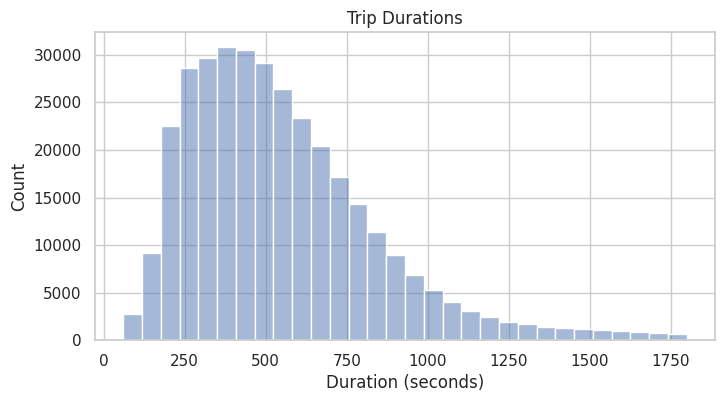

In [3]:
# Keep only the "free" (short) trips for the rest of the notebook.
commute = trips[trips["Duration"] < 1800]

# OOP plotting API: create a Figure with a single Axes, then draw onto that Axes.
fig, ax = plt.subplots(figsize=(8, 4))

# Seaborn histogram: counts how many trips fall into each duration bin.
sns.histplot(
    data=commute,   # explicitly pass the filtered DataFrame
    x="Duration",   # column to bin along the x-axis
    bins=30,        # coarser binning than the next chart
    alpha=0.5,      # semi-transparent so overlaps remain visible
    ax=ax,          # direct output to OUR Axes
)

# Configure the Axes AFTER plotting (OOP style: each Axes owns its labels/title).
ax.set_title("Trip Durations")
ax.set_xlabel("Duration (seconds)")
plt.show()


### Histogram with 80 bins

More bins reveal finer detail, but the overall shape barely changes.


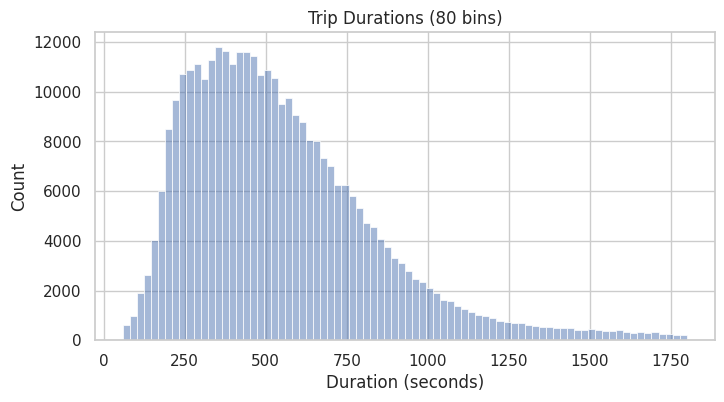

In [4]:
fig, ax = plt.subplots(figsize=(8, 4))

sns.histplot(
    data=commute,   # same filtered DataFrame as before
    x="Duration",   # column to bin along the x-axis
    bins=80,        # finer-grained bins
    alpha=0.5,      # semi-transparent for visual overlap
    ax=ax,          # direct output to OUR Axes
)

ax.set_title("Trip Durations (80 bins)")
ax.set_xlabel("Duration (seconds)")
plt.show()


## Exploring the Data with `group` and `pivot`

### Most popular start stations

We use `groupby` to identify the most highly used Start Station.


In [5]:
# Long method chain - one step per line for readability.
starts = (
    commute
    .groupby("Start Station")        # 1) split rows by Start Station name
    .size()                           # 2) count rows in each group -> Series
    .reset_index(name="count")        # 3) turn the Series into a 2-column DataFrame
    .sort_values(                     # 4) busiest stations first
        by="count",
        ascending=False,
    )
)
starts.head()


,Start Station,count
49,San Francisco Caltrain (Townsend at 4th),25858
50,San Francisco Caltrain 2 (330 Townsend),21523
23,Harry Bridges Plaza (Ferry Building),15543
65,Temporary Transbay Terminal (Howard at Beale),14298
2,2nd at Townsend,13674


The largest number of trips started at the Caltrain Station on Townsend and 4th in San Francisco — riders take the train into the city, then hop on a shared bike to reach their next destination.


### Count trips for each start-end pair

`groupby` can also classify rentals by both Start Station *and* End Station.


In [6]:
# Pass a LIST of column names to group by two columns simultaneously.
start_end = commute.groupby(["Start Station", "End Station"]).size()
start_end.head()


Start Station  End Station      
2nd at Folsom  2nd at Folsom         54
               2nd at South Park    295
               2nd at Townsend      437
               5th at Howard        113
               Beale at Market      127
dtype: int64

- `groupby` with two columns produces a Series indexed by a **MultiIndex**.
- `"Start Station"` is the 1st level; `"End Station"` is the 2nd level.


In [7]:
start_end.index


MultiIndex([(                                '2nd at Folsom', ...),
            (                                '2nd at Folsom', ...),
            (                                '2nd at Folsom', ...),
            (                                '2nd at Folsom', ...),
            (                                '2nd at Folsom', ...),
            (                                '2nd at Folsom', ...),
            (                                '2nd at Folsom', ...),
            (                                '2nd at Folsom', ...),
            (                                '2nd at Folsom', ...),
            (                                '2nd at Folsom', ...),
            ...
            ('Yerba Buena Center of the Arts (3rd @ Howard)', ...),
            ('Yerba Buena Center of the Arts (3rd @ Howard)', ...),
            ('Yerba Buena Center of the Arts (3rd @ Howard)', ...),
            ('Yerba Buena Center of the Arts (3rd @ Howard)', ...),
            ('Yerba Buena Center

- Use `reset_index` to flatten the MultiIndex back into regular columns.
- `name="count"` gives the aggregated values their own column name.


In [8]:
start_end = start_end.reset_index(name="count")
start_end.head()


,Start Station,End Station,count
0,2nd at Folsom,2nd at Folsom,54
1,2nd at Folsom,2nd at South Park,295
2,2nd at Folsom,2nd at Townsend,437
3,2nd at Folsom,5th at Howard,113
4,2nd at Folsom,Beale at Market,127


Fifty-four trips both started and ended at the station on 2nd at Folsom. A much larger number (437) went between 2nd at Folsom and 2nd at Townsend.


### Using `pivot` to show all combinations

- `pivot_table` shows a contingency table of ALL possible (Start, End) combinations.
- Combinations with no trips appear as the `fill_value`.
- The `index=` argument labels the **rows**; `columns=` labels the **columns**.
- A train station and a BART station near *Beale at Market* explain its high counts.


In [9]:
pivot_table = commute.pivot_table(
    index="Start Station",   # rows of the output
    columns="End Station",   # columns of the output
    values="Duration",       # column we aggregate over
    aggfunc="count",         # count trips instead of averaging duration
    fill_value=0,            # replace NaN (no trips) with 0
)
pivot_table.head()


End Station,2nd at Folsom,2nd at South Park,2nd at Townsend,5th at Howard,Adobe on Almaden,Arena Green / SAP Center,Beale at Market,Broadway St at Battery St,California Ave Caltrain Station,Castro Street and El Camino Real,...,South Van Ness at Market,Spear at Folsom,St James Park,Stanford in Redwood City,Steuart at Market,Temporary Transbay Terminal (Howard at Beale),Townsend at 7th,University and Emerson,Washington at Kearny,Yerba Buena Center of the Arts (3rd @ Howard)
Start Station,,,,,,,,,,,,,,,,,,,,,
2nd at Folsom,54,295,437,113,0,0,127,67,0,0,...,46,327,0,0,128,414,347,0,142,83
2nd at South Park,190,164,151,177,0,0,79,89,0,0,...,41,209,0,0,224,437,309,0,142,180
2nd at Townsend,554,71,185,148,0,0,183,279,0,0,...,50,407,0,0,1644,486,418,0,72,174
5th at Howard,107,180,92,83,0,0,59,119,0,0,...,102,100,0,0,371,561,313,0,47,90
Adobe on Almaden,0,0,0,0,11,7,0,0,0,0,...,0,0,10,0,0,0,0,0,0,0


### Shortest time between stations

- Reuse `pivot_table`, but ask for the **minimum** duration in each cell.
- `Duration` stays as the value column; `aggfunc="min"` picks the fastest ride per pair.


In [10]:
pivot_table_min = commute.pivot_table(
    index="Start Station",   # rows of the output
    columns="End Station",   # columns of the output
    values="Duration",       # column we aggregate over
    aggfunc="min",           # take the fastest ride per pair
    fill_value=0,            # pairs with no trips -> 0
)
pivot_table_min.head()


End Station,2nd at Folsom,2nd at South Park,2nd at Townsend,5th at Howard,Adobe on Almaden,Arena Green / SAP Center,Beale at Market,Broadway St at Battery St,California Ave Caltrain Station,Castro Street and El Camino Real,...,South Van Ness at Market,Spear at Folsom,St James Park,Stanford in Redwood City,Steuart at Market,Temporary Transbay Terminal (Howard at Beale),Townsend at 7th,University and Emerson,Washington at Kearny,Yerba Buena Center of the Arts (3rd @ Howard)
Start Station,,,,,,,,,,,,,,,,,,,,,
2nd at Folsom,61,61,137,215,0,0,219,351,0,0,...,673,154,0,0,219,112,399,0,266,145
2nd at South Park,97,60,67,300,0,0,343,424,0,0,...,801,219,0,0,322,195,324,0,378,212
2nd at Townsend,164,77,60,384,0,0,417,499,0,0,...,727,242,0,0,312,261,319,0,464,299
5th at Howard,268,86,423,68,0,0,387,555,0,0,...,383,382,0,0,384,279,330,0,269,128
Adobe on Almaden,0,0,0,0,84,305,0,0,0,0,...,0,0,409,0,0,0,0,0,0,0


- A very quick trip (271 s = ~4.5 min) went from *Beale at Market* to *2nd at Folsom* (about five blocks away).
- There are no bike trips between the *2nd Avenue* stations and *Adobe on Almaden* — they sit in different cities.


## Drawing Maps with Folium

- `stations` contains geographical info for each bike station.
- Columns of interest:
  - `lat`, `long`: coordinates
  - `landmark`: the city the station belongs to
  - `name`: a human-readable label


In [11]:
# Use Path's `/` operator to build the path; `path_data + "..."` would raise TypeError on a Path object.
stations = pd.read_csv(path_data / "station.csv")
stations.head()


,station_id,name,lat,long,dockcount,landmark,installation
0,2,San Jose Diridon Caltrain Station,37.329732,-121.901782,27,San Jose,8/6/2013
1,3,San Jose Civic Center,37.330698,-121.888979,15,San Jose,8/5/2013
2,4,Santa Clara at Almaden,37.333988,-121.894902,11,San Jose,8/6/2013
3,5,Adobe on Almaden,37.331415,-121.893200,19,San Jose,8/5/2013
4,6,San Pedro Square,37.336721,-121.894074,15,San Jose,8/7/2013


### Map of all stations

- We use [`folium.Marker`](https://python-visualization.github.io/folium/latest/user_guide/ui_elements/markers.html) to drop a pin per station.
- Each marker needs latitude, longitude, and (optionally) a popup label.


In [12]:
# Folium: interactive Leaflet-based maps from Python.
# Docs: https://python-visualization.github.io/folium/latest/
import folium


def plot_map(data, lat_col="lat", long_col="long", label_col=None):
    """Drop a Folium marker on `data` for each row, centered on the mean point."""
    # Compute mean coordinates so the map starts centered on the data cloud.
    center_lat = data[lat_col].mean()
    center_long = data[long_col].mean()

    # Create the base map at that center.
    m = folium.Map(
        location=[center_lat, center_long],  # required to pin the view
        zoom_start=10,                       # wide enough to cover the Bay Area
    )

    # Add one marker per row of the DataFrame.
    for _, row in data.iterrows():
        marker = folium.Marker(
            location=[row[lat_col], row[long_col]],
            popup=row[label_col] if label_col else None,
        )
        marker.add_to(m)

    return m


In [13]:
stations_map = plot_map(
    data=stations,
    lat_col="lat",
    long_col="long",
    label_col="name",
)
stations_map


- The map uses [OpenStreetMap](http://www.openstreetmap.org/), an open online mapping system similar to Google Maps.
- Zoom in to San Francisco to see how the stations are distributed.
- Click on a marker to see which station it is.


### San Francisco stations as colored circles

We can also represent points with colored circles via [`folium.CircleMarker`](https://python-visualization.github.io/folium/latest/user_guide/ui_elements/markers.html#circle-marker-and-circle).


In [14]:
# Pick only the San Francisco stations.
sf = stations[stations["landmark"] == "San Francisco"]

# Keep only the columns we need to draw the map.
sf_map_data = sf[["lat", "long", "name"]]

# Compute SF-only mean coordinates to center the map on downtown SF.
sf_center_lat = sf["lat"].mean()
sf_center_long = sf["long"].mean()

# Base map centered on SF.
sf_map = folium.Map(
    location=[sf_center_lat, sf_center_long],  # required
    zoom_start=10,                             # wide SF view
)

# Drop a green filled circle on every SF station.
for _, row in sf_map_data.iterrows():
    circle = folium.CircleMarker(
        location=[row["lat"], row["long"]],
        color="green",   # green outline for SF stations
        fill=True,       # fill the circle with the color
    )
    circle.add_to(sf_map)

sf_map


## More Informative Maps: An Application of `join`

- Bike stations span five different Bay Area cities.
- To distinguish them visually, we assign each city a unique color.
- Then we `merge` (a.k.a. `join`) `stations` with this color lookup.


### Assign each city a color


In [15]:
# Get unique city names from the `landmark` column.
cities = stations["landmark"].unique()

# Build a small lookup table mapping each city to a color.
colors = pd.DataFrame({
    "city": cities,
    "color": ["blue", "red", "green", "orange", "purple"],
})
colors


,city,color
0,San Jose,blue
1,Redwood City,red
2,Mountain View,green
3,Palo Alto,orange
4,San Francisco,purple


### Join `stations` with `colors`

`merge` matches rows where `stations.landmark == colors.city`.


In [16]:
joined = stations.merge(
    colors,
    left_on="landmark",  # column in left DataFrame to match on
    right_on="city",     # column in right DataFrame to match on
)

# Pick only the columns we need to draw a colored map.
colored = joined[["lat", "long", "name", "color"]]
colored.head()


,lat,long,name,color
0,37.329732,-121.901782,San Jose Diridon Caltrain Station,blue
1,37.330698,-121.888979,San Jose Civic Center,blue
2,37.333988,-121.894902,Santa Clara at Almaden,blue
3,37.331415,-121.893200,Adobe on Almaden,blue
4,37.336721,-121.894074,San Pedro Square,blue


### Map with city colors


In [17]:
# Mean coordinates across ALL stations - centers the map on the Bay Area.
all_center_lat = colored["lat"].mean()
all_center_long = colored["long"].mean()

colored_map = folium.Map(
    location=[all_center_lat, all_center_long],  # required
    zoom_start=10,                               # Bay Area view
)

# Draw one filled circle per station, colored by city.
for _, row in colored.iterrows():
    circle = folium.CircleMarker(
        location=[row["lat"], row["long"]],
        color=row["color"],  # per-city color from the merge
        fill=True,           # filled circle
        popup=row["name"],   # show station name on click
    )
    circle.add_to(colored_map)

colored_map


Now the markers have five different colors for the five different cities.


### Sized markers by trip volume

To see where most bike rentals originate, let's identify the start stations again.


In [18]:
starts = (
    commute
    .groupby("Start Station")        # 1) split by start station
    .size()                           # 2) count rows per group
    .reset_index(name="count")        # 3) flatten to a 2-column DataFrame
    .sort_values(                     # 4) busiest first
        by="count",
        ascending=False,
    )
)
starts.head()


,Start Station,count
49,San Francisco Caltrain (Townsend at 4th),25858
50,San Francisco Caltrain 2 (330 Townsend),21523
23,Harry Bridges Plaza (Ferry Building),15543
65,Temporary Transbay Terminal (Howard at Beale),14298
2,2nd at Townsend,13674


We include the geographical data needed to map these stations by joining `starts` with `stations`.


In [19]:
station_starts = stations.merge(
    starts,
    left_on="name",            # station name in `stations`
    right_on="Start Station",  # start station name in `starts`
)
station_starts.head()


,station_id,name,lat,long,dockcount,landmark,installation,Start Station,count
0,2,San Jose Diridon Caltrain Station,37.329732,-121.901782,27,San Jose,8/6/2013,San Jose Diridon Caltrain Station,4899
1,3,San Jose Civic Center,37.330698,-121.888979,15,San Jose,8/5/2013,San Jose Civic Center,574
2,4,Santa Clara at Almaden,37.333988,-121.894902,11,San Jose,8/6/2013,Santa Clara at Almaden,1888
3,5,Adobe on Almaden,37.331415,-121.893200,19,San Jose,8/5/2013,Adobe on Almaden,522
4,6,San Pedro Square,37.336721,-121.894074,15,San Jose,8/7/2013,San Pedro Square,1321


- We extract just the data needed for the map.
- We attach a color (from `colored`) and a *radius* proportional to the start count.
- The constant `0.006` was chosen empirically so circles render at a readable scale.


In [20]:
merged_df = colored.merge(
    station_starts,
    left_on="name",
    right_on="Start Station",
    suffixes=("", "_y"),       # keep left names as-is; suffix right collisions
)

# Keep just what the map needs: position, label, color, and the count for sizing.
starts_map_data = merged_df[["lat", "long", "name", "color", "count"]]
starts_map_data.head()


,lat,long,name,color,count
0,37.329732,-121.901782,San Jose Diridon Caltrain Station,blue,4899
1,37.330698,-121.888979,San Jose Civic Center,blue,574
2,37.333988,-121.894902,Santa Clara at Almaden,blue,1888
3,37.331415,-121.893200,Adobe on Almaden,blue,522
4,37.336721,-121.894074,San Pedro Square,blue,1321


In [21]:
# Center the map on the mean of the start-station coordinates.
starts_center_lat = starts_map_data["lat"].mean()
starts_center_long = starts_map_data["long"].mean()

starts_map = folium.Map(
    location=[starts_center_lat, starts_center_long],  # required
    zoom_start=10,                                     # Bay Area view
)

# Each station gets a filled circle whose RADIUS is scaled by its trip count.
for _, row in starts_map_data.iterrows():
    circle = folium.CircleMarker(
        location=[row["lat"], row["long"]],
        radius=row["count"] * 0.006,  # scale by popularity
        color=row["color"],            # color by city
        fill=True,                     # filled circle
        popup=row["name"],             # station name on click
    )
    circle.add_to(starts_map)

starts_map


That huge blob in San Francisco shows that the eastern section of the city is the unrivaled capital of bike rentals in the Bay Area.


---


## References

- [Chapter 8.5 - Computational and Inferential Thinking: The Foundations of Data Science](https://inferentialthinking.com/chapters/08/5/Bike_Sharing_in_the_Bay_Area.html)
